In [6]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.datasets import mnist

(x_train_image, y_train_lable), (x_test_image, y_test_label) = mnist.load_data()



In [7]:
print("x_train_image shape:", x_train_image.shape)
print("first data of x_train_image:", x_train_image[0])
print("first data of y_train_lable:", y_train_lable[0])

x_train_image shape: (60000, 28, 28)
first data of x_train_image: [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0

In [8]:
from tensorflow.keras.utils import to_categorical #import to_categorical function from keras.utils
x_train = x_train_image.reshape(x_train_image.shape[0], 28, 28, 1) #reshape the x_train_image to (60000, 28, 28, 1)
#This is keras way to reshape the image data to 4D tensor, where 60000 is the number of images, 28 is the height and width of the image, and 1 is the number of channels (grayscale).
x_test = x_test_image.reshape(x_test_image.shape[0], 28, 28, 1) #reshape the x_test_image to (10000, 28, 28, 1)
y_train = to_categorical(y_train_lable, num_classes=10) #convert the y_train_lable to one-hot encoded vector with 10 classes
y_test = to_categorical(y_test_label, num_classes=10) #convert the y_test_label to one-hot encoded vector with 10 classes
print("x_train shape:", x_train.shape) #print the shape of x_train
print("first data of y_train:", y_train[0]) #print the first data of y_train

x_train shape: (60000, 28, 28, 1)
first data of y_train: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [9]:
#select the ML model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D
model = Sequential() #create a sequential model
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1))) #add a convolutional layer with 32 filters, kernel size of 3x3, relu activation function, and input shape of (28, 28, 1)
model.add(MaxPooling2D(pool_size=(2, 2))) #add a max pooling
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu')) #add a convolutional layer with 64 filters, kernel size of 3x3, relu activation function
model.add(MaxPooling2D(pool_size=(2, 2))) #add a max pooling
model.add(Dropout(0.25)) #add a dropout layer with 0.25 dropout rate
model.add(Flatten()) #flatten the output of the previous layer
model.add(Dense(128, activation='relu')) #add a dense layer with 128 units and relu activation function
model.add(Dropout(0.5)) #add a dropout layer with 0.5 dropout rate
model.add(Dense(10, activation='softmax')) #add a dense layer with 10 units and softmax activation function.

model.compile(optimizer='rmsprop',loss='categorical_crossentropy',metrics=['accuracy']) #compile the model with rmsprop optimizer, categorical crossentropy loss function, and accuracy metric



In [10]:
model.fit(x_train,y_train,validation_split = 0.3,epochs=5,batch_size=128) #train the model with x_train and y_train, validation split of 0.3, 5 epochs, and batch size of 128


Epoch 1/5


2026-07-13 18:28:27.694956: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


329/329 [==============================] - ETA: 0s - loss: 8.1329 - accuracy: 0.8442

2026-07-13 18:28:35.464788: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


329/329 [==============================] - 9s 26ms/step - loss: 8.1329 - accuracy: 0.8442 - val_loss: 1.5660 - val_accuracy: 0.9704
Epoch 2/5
329/329 [==============================] - 8s 23ms/step - loss: 3.5853 - accuracy: 0.9437 - val_loss: 1.9940 - val_accuracy: 0.9701
Epoch 3/5
329/329 [==============================] - 8s 24ms/step - loss: 3.5622 - accuracy: 0.9539 - val_loss: 1.8423 - val_accuracy: 0.9796
Epoch 4/5
329/329 [==============================] - 8s 23ms/step - loss: 3.2949 - accuracy: 0.9623 - val_loss: 1.7291 - val_accuracy: 0.9796
Epoch 5/5
329/329 [==============================] - 8s 24ms/step - loss: 2.9293 - accuracy: 0.9673 - val_loss: 2.2179 - val_accuracy: 0.9742


In [11]:
score = model.evaluate(x_test,y_test)
print('Test accuracy:', score[1]) #print the test accuracy

313/313 [==============================] - 3s 10ms/step - loss: 1.8987 - accuracy: 0.9761
Test accuracy: 0.9761000275611877


1/1 [==============================] - 0s 19ms/step
[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.] converted the format to get the predicted number: 7


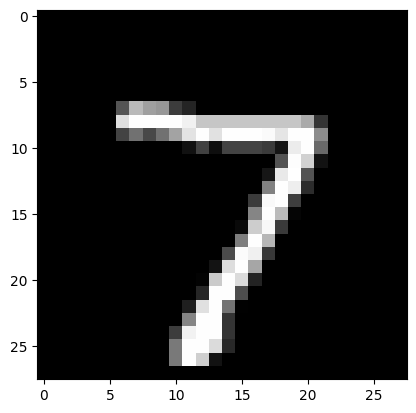

In [17]:
pred=model.predict(x_test[0].reshape(1,28,28,1)) #predict the first images of x_test
print(pred[0],'converted the format to get the predicted number:',pred.argmax())

import matplotlib.pyplot as plt
plt.imshow(x_test[0].reshape(28,28),cmap='gray')